<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №2
## Амплитудная и фазовая модуляция: генерация, спектры, демодуляция и устойчивость к шумам

**Цель работы:**
- Научиться генерировать сигналы с амплитудной (АМ) и фазовой (ФМ) модуляцией.
- Исследовать спектральные характеристики модулированных сигналов.
- Изучить влияние индекса модуляции на спектр ФМ сигнала.
- Освоить демодуляцию АМ и ФМ с помощью преобразования Гильберта.
- Оценить устойчивость АМ и ФМ к амплитудному шуму на примере реального аудиосигнала.

**Необходимое ПО:** Python 3, библиотеки `numpy`, `matplotlib`, `scipy`, `ipywidgets`, `IPython.display`. Работа выполняется в Jupyter Notebook / Google Colab.

**Формат сдачи:** один Jupyter Notebook с кодом, графиками и текстовыми выводами. Имя файла: `2_Фамилия.ipynb`.

## Часть 1. Генерация и визуализация модулированных сигналов

### 1.1. Импорт библиотек и параметры

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from scipy.signal import hilbert
import ipywidgets as widgets
from IPython.display import Audio, display

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

# Параметры дискретизации для демонстрации
fs = 10000                     # частота дискретизации (Гц)
T = 0.1                        # длительность сигнала (с)
t = np.linspace(0, T, int(fs*T), endpoint=False)

# Несущая
fc = 1000                      # частота несущей (Гц)
Ac = 1.0                       # амплитуда несущей

### 1.2. Модулирующий сигнал

В качестве модулирующего сигнала используйте сумму двух синусоид с частотами 100 Гц и 150 Гц, нормализованную к диапазону [-1, 1]. Постройте его график.

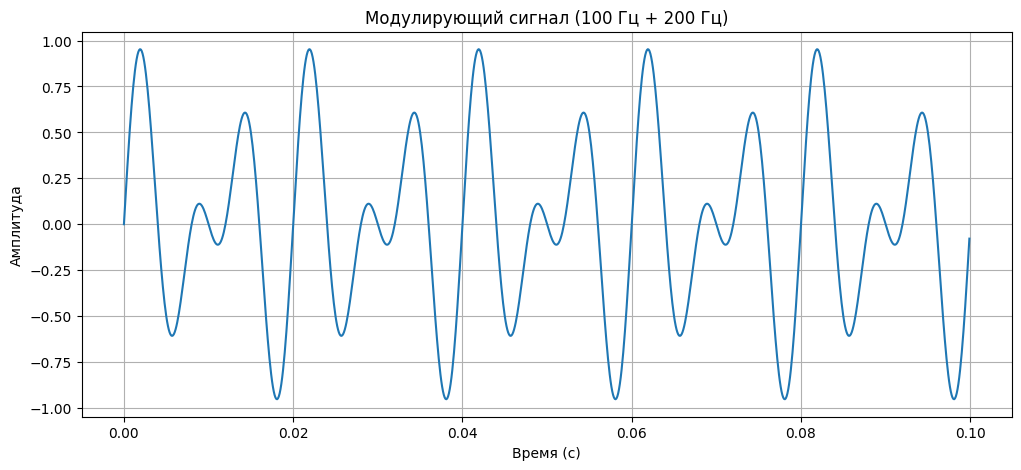

In [2]:
fm1 = 100
fm2 = 150
m_t = 0.5 * np.sin(2 * np.pi * fm1 * t) + 0.5 * np.sin(2 * np.pi * fm2 * t) # модулирующий сигнал - сумма двух синусоид со значениями в интервале [-1,1]

plt.figure()
plt.plot(t, m_t)
plt.title('Модулирующий сигнал (100 Гц + 200 Гц)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

### 1.3. Амплитудная модуляция (АМ)

Формула АМ:
$$s_{AM}(t) = A_c [1 + a_{AM}\cdot m(t)] \cos(2\pi f_c t)
$$
Параметр $a_{AM}$ регулирует _глубину модуляции_, он не может быть больше 1 (при $a_{AM}>1$ и исходном сигнале $m(t)$, нормализованном на единицу, амплитуда результирующего сигнала в некоторые промежутки времени становится отрицательной).

In [3]:
a_am = 0.2
s_am = Ac * (1 + a_am * m_t) * np.cos(2 * np.pi * fc * t)

### 1.4. Фазовая модуляция (ФМ)

Формула ФМ:
$$
s_{PM}(t) = A_c \cos(2\pi f_c t + \beta \cdot m(t)),
$$

где $\beta$ – индекс фазовой модуляции.

In [4]:
beta_pm = 5
s_pm = Ac * np.cos(2 * np.pi * fc * t + beta_pm * m_t)

Постройте на одном графике модулирующий сигнал и оба модулированных сигнала (АМ, ФМ). Оси и графики должны быть подписаны.

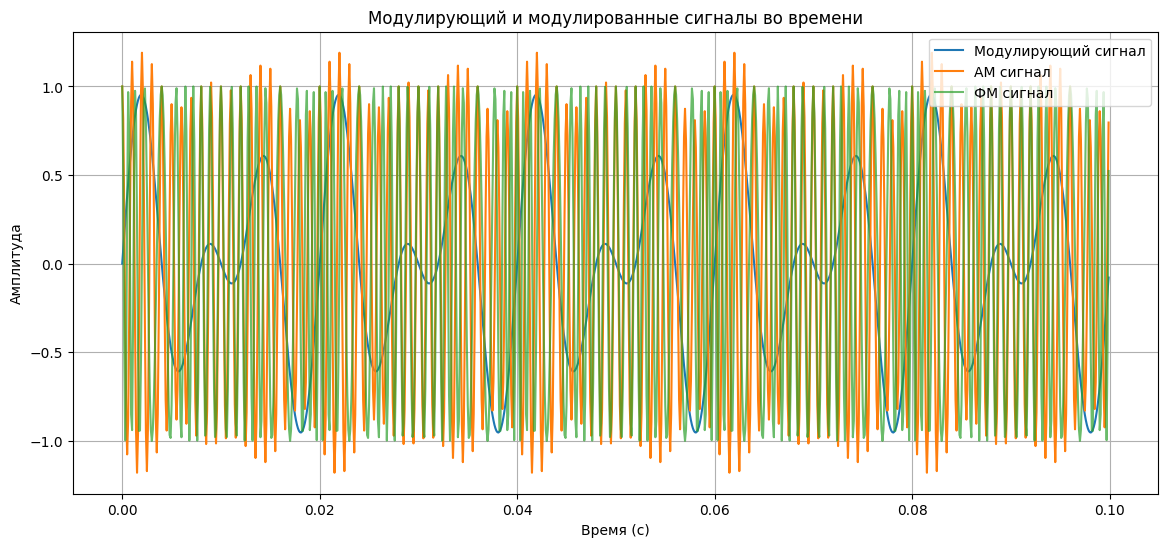

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(t, m_t, label='Модулирующий сигнал')
plt.plot(t, s_am, label='АМ сигнал')
plt.plot(t, s_pm, label='ФМ сигнал', alpha=0.7)
plt.title('Модулирующий и модулированные сигналы во времени')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)
plt.show()

## Часть 2. Спектральный анализ модулированных сигналов

### 2.1. Функция построения амплитудного спектра
Реализуйте функцию построения амплитудного спектра ```plot_spectrum(s,fs,title)```
Значения аргументов:
* `s` - массив, содержащий значения сигнала
* `fs` - частота отсчётов сигнала
* `title` - заголовок графика, выводимый сверху

На графике по горизонтальной оси должна быть отложена частота в герцах, а по вертикальной - амплитуда гармоники. График должен строиться только для положительных значений частоты. Оси должны быть подписаны.

In [6]:
def plot_spectrum(s, fs, title):
    N = len(s)
    X = np.fft.fft(s)
    freqs = np.fft.fftfreq(N, 1/fs)
    half_N = N // 2
    
    plt.figure()
    plt.plot(freqs[:half_N], np.abs(X[:half_N]) * 2 / N)
    plt.title(title)
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.xlim(0, fs / 2)
    plt.show()

### 2.2. Спектр АМ

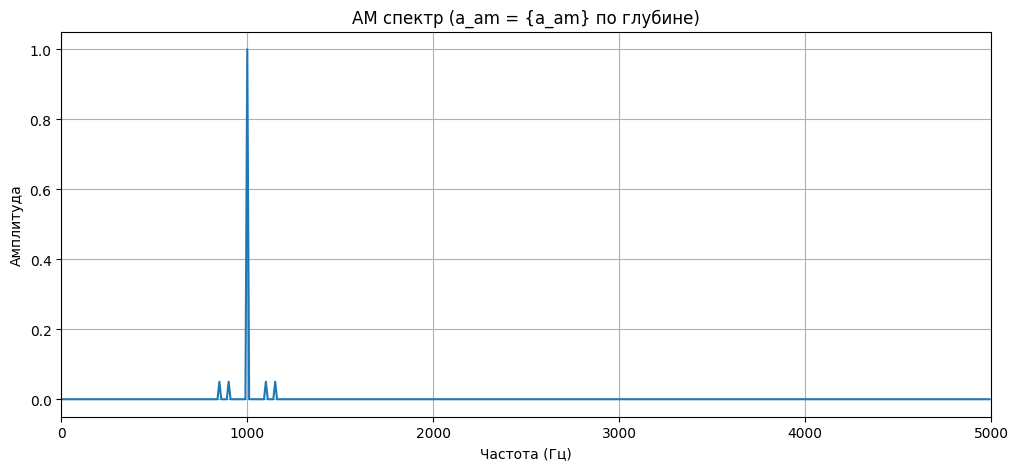

In [8]:
plot_spectrum(s_am, fs, 'АМ спектр (a_am = {a_am} по глубине)')

### 2.3. Спектр ФМ при разных индексах модуляции

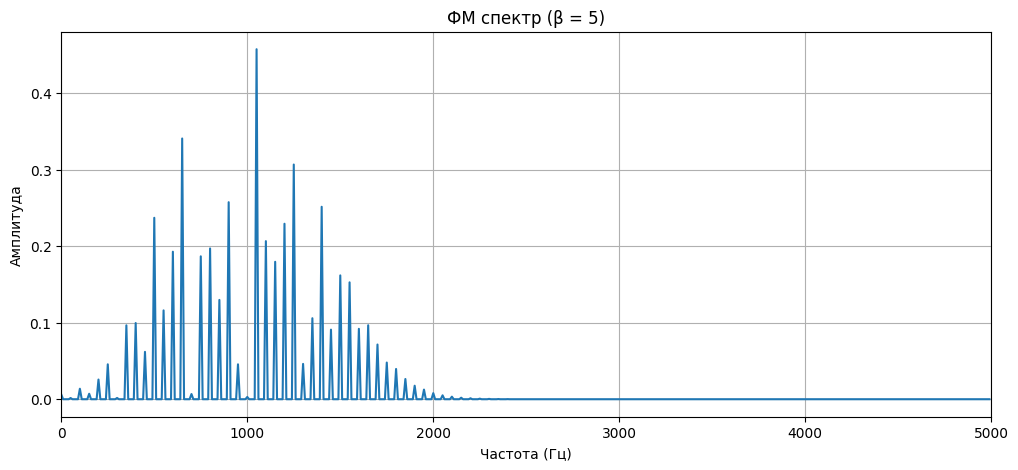

In [9]:
plot_spectrum(s_pm, fs, f'ФМ спектр (β = {beta_pm})')

Для ФМ постройте на одном графике спектры для разных индексов модуляции (например, β = 0.1, 0.3, 1, 2, 5, 10). Оси и графики должны быть подписаны.

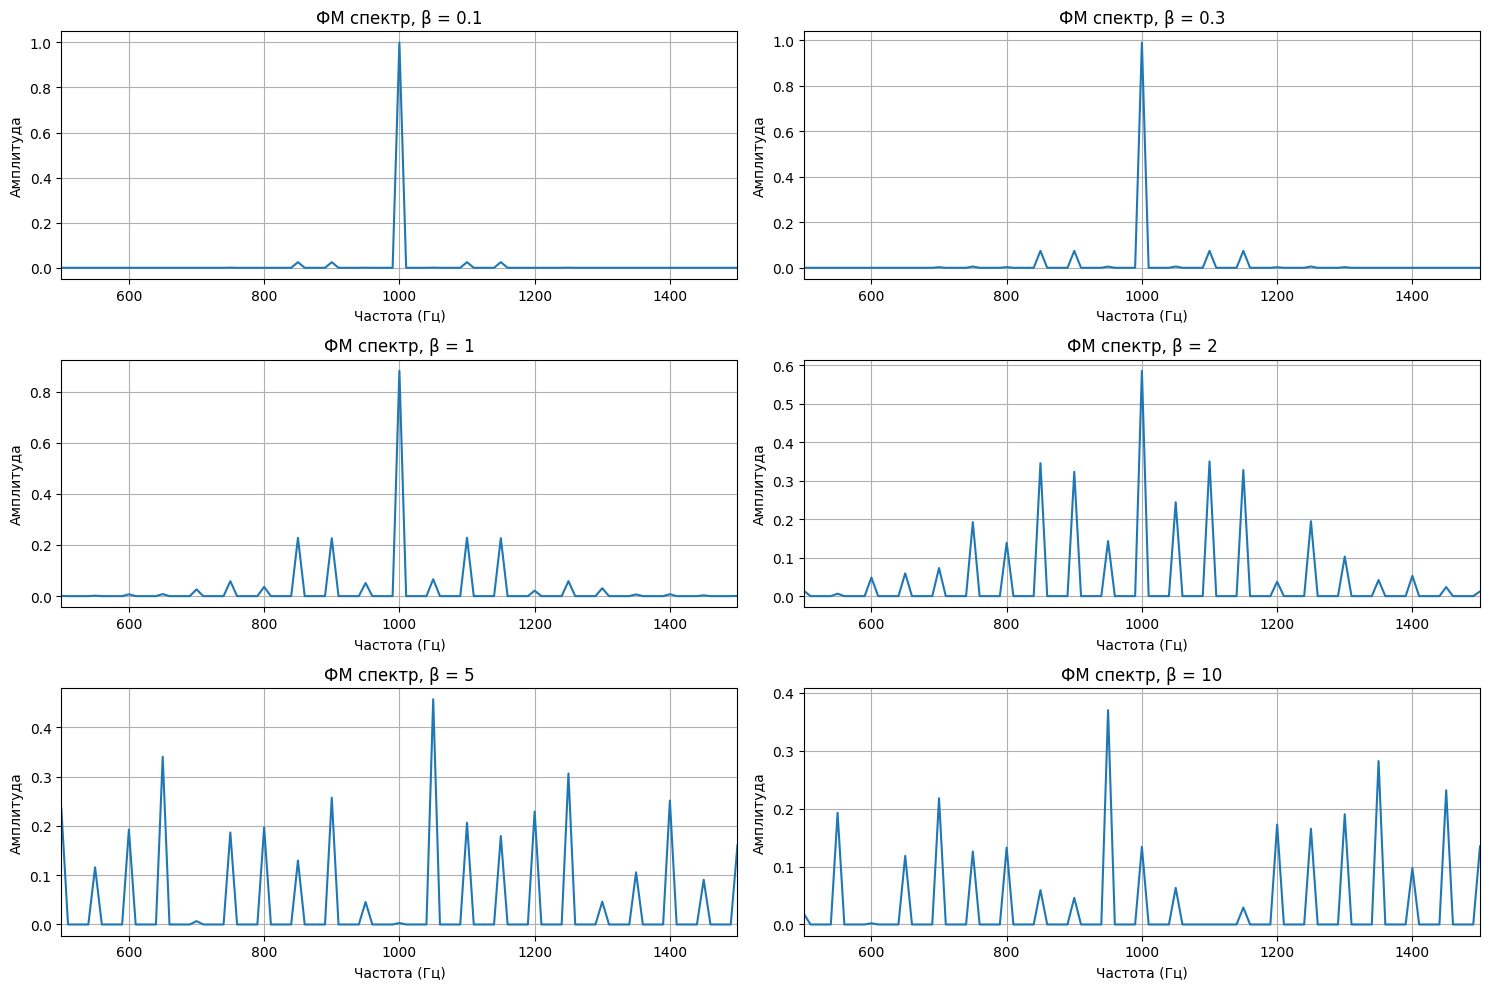

In [10]:
betas = [0.1, 0.3, 1, 2, 5, 10]
plt.figure(figsize=(15, 10))

for i, b in enumerate(betas):
    s = Ac * np.cos(2 * np.pi * fc * t + b * m_t)
    N = len(s)
    X = np.fft.fft(s)
    freqs = np.fft.fftfreq(N, 1/fs)
    half_N = N // 2
    
    plt.subplot(3, 2, i + 1)
    plt.plot(freqs[:half_N], np.abs(X[:half_N]) * 2 / N)
    plt.title(f'ФМ спектр, β = {b}')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Амплитуда')
    plt.grid(True)
    plt.xlim(500, 1500)

plt.tight_layout()
plt.show()

### 2.4. Интерактивное исследование спектра ФМ
Создайте интерактивный график для исследования зависимости спектра ФМ-сигнала от индекса модуляции.

In [11]:
def pm_spectrum(beta=5):
    s = Ac * np.cos(2 * np.pi * fc * t + beta * m_t)
    plot_spectrum(s, fs, f'ФМ спектр (β = {beta})')

widgets.interact(pm_spectrum, beta=widgets.FloatSlider(min=0.1, max=20, step=0.1, value=5));

interactive(children=(FloatSlider(value=5.0, description='beta', max=20.0, min=0.1), Output()), _dom_classes=(…

**Вопросы:**
- Почему спектр АМ содержит только пять ярко выраженных компоненты (несущая и по две боковых с каждой стороны от неё)?
- Опишите, как выглядит спектр ФМ при малых β?
- Что происходит с амплитудой несущей и боковыми полосами ФМ при увеличении β?

- В спектре АМ наблюдаются пять заметных линий, потому что модулирующий сигнал задан как сумма двух синусоид с частотами 100 и 150 Гц. При амплитудной модуляции каждая такая составляющая создаёт две боковые полосы около несущей, а сама несущая остаётся в спектре. В итоге получаем одну линию несущей и по две боковые от каждой гармоники.
- При небольших значениях β спектр ФМ остаётся сравнительно узким. Наиболее заметна несущая составляющая, а рядом с ней появляются только ближайшие боковые полосы. Поэтому по виду такой спектр близок к АМ: основная энергия сосредоточена в центре и в первых соседних компонентах.
- Когда β увеличивается, энергия сигнала перераспределяется: несущая становится слабее, а боковых составляющих появляется больше. Из-за этого спектр ФМ расширяется, и всё большая часть мощности уходит из центральной линии в боковые полосы.

## Часть 3. Демодуляция сигналов

### 3.1. Демодуляция АМ с помощью преобразования Гильберта

Преобразование Гильберта позволяет получить аналитический сигнал, огибающая которого содержит исходное сообщение.

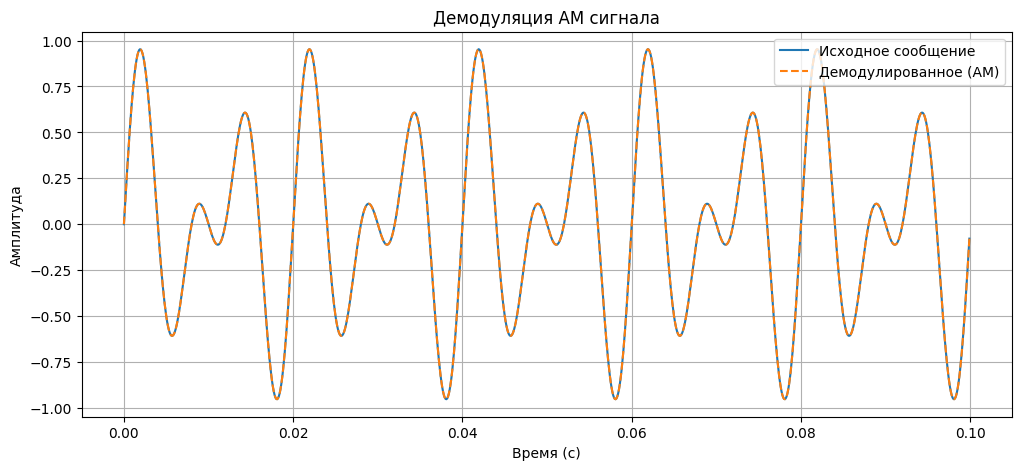

In [12]:
# Аналитический сигнал для АМ
analytic_am = hilbert(s_am)
envelope = np.abs(analytic_am) # огибающая = 1 + m(t)

# Убираем постоянную составляющую
demod_am = envelope - Ac

# Нормализуем сигнал
demod_am = demod_am / (Ac * a_am)

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_am, '--', label='Демодулированное (АМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция АМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

Вычислите среднеквадратичную ошибку между исходным и восстановленным сообщением с помощью функции `np.std`.

In [13]:
mse = np.std(m_t - demod_am)
print(f'Среднеквадратичная ошибка (АМ): {mse}')

Среднеквадратичная ошибка (АМ): 8.090521957314932e-14


### 3.2. Демодуляция ФМ сигнала

Для ФМ информация заключена в отклонении фазы от линейного тренда. Используем аналитический сигнал и выделим мгновенную фазу.

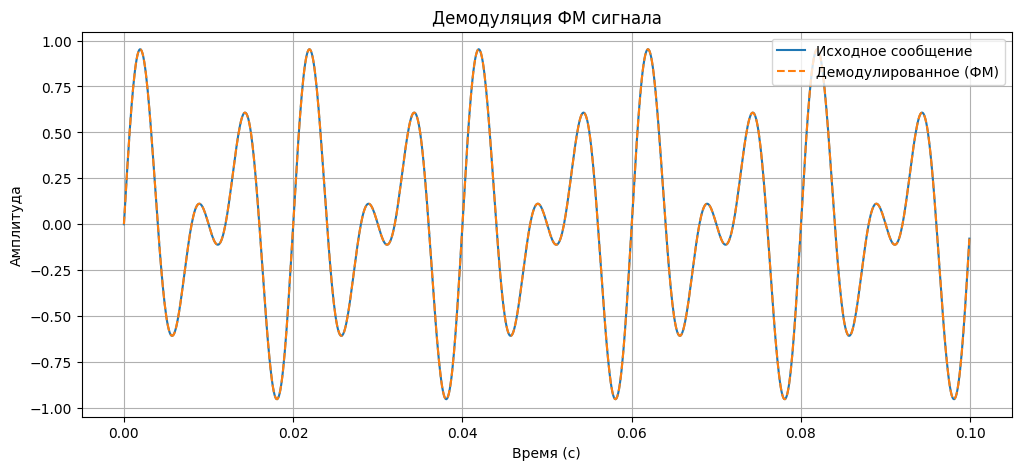

In [14]:
# Аналитический сигнал для ФМ
analytic_pm = hilbert(s_pm)
inst_phase = np.unwrap(np.angle(analytic_pm))   # развернутая фаза

# Убираем линейную составляющую (фаза несущей)
phase_no_carrier = inst_phase - 2 * np.pi * fc * t

# Убираем постоянную составляющую (может появиться в общем случае при наличии шумов, искажений и т. п.)
demod_pm = phase_no_carrier - np.mean(phase_no_carrier)

# Нормализуем сигнал
demod_pm = demod_pm / beta_pm

# Сравнение с исходным
plt.figure()
plt.plot(t, m_t, label='Исходное сообщение')
plt.plot(t, demod_pm, '--', label='Демодулированное (ФМ)')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Демодуляция ФМ сигнала')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:** Почему важно использовать `np.unwrap` для фазы?

Использование `np.unwrap` необходимо из-за того, что функция `np.angle` ограничивает значения фазы интервалом от −π до π. В результате, когда реальная фаза сигнала непрерывно изменяется, на графике появляются искусственные скачки на величину 2π.

Функция `np.unwrap` устраняет такие разрывы, «разворачивая» фазу и делая её плавной. Это позволяет получить корректную непрерывную зависимость фазы, что особенно важно при дальнейшем анализе и извлечении модулирующего сигнала.

## Часть 4. Устойчивость к шумам

В этой части мы работаем с реальным аудиофайлом. Для примера WAV-файл расположен в том же репозитории, что и ноутбук по адресу `data/sample-3s.wav`, но его надо загрузить в Google Colab.

### 4.1. Загрузка аудио (или генерация тестового сигнала)

In [18]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/sample-3s.wav"

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.


In [20]:
fs_audio, melody_stereo = wavfile.read('../data/sample-3s.wav') # читаем wav-файл в массив numpy, в файл записан стереосигнал, поэтому melody_stereo будет содержать две дорожки (левую и правую)

melody = melody_stereo[:,0] # переходим к моносигналу, беря только одну из двух дорожек
melody = melody / np.max(np.abs(melody)) # нормализуем сигнал, чтобы корректно работала амплитудная модуляция

t_audio = np.linspace(0, melody.shape[0]/fs_audio, melody.shape[0], endpoint=False) # для визуализации создаём также массив временных отсчётов

print(f"Частота дискретизации: {fs_audio} Гц")
print(f"Длина временного ряда: {len(melody)}")
print(f"Тип данных: {melody.dtype}")

print("Исходное аудио:")
display(Audio(melody, rate=fs_audio))

Частота дискретизации: 44100 Гц
Длина временного ряда: 140928
Тип данных: float64
Исходное аудио:


Постройте графики самого сигнала и его спектра. Подпишите оси.

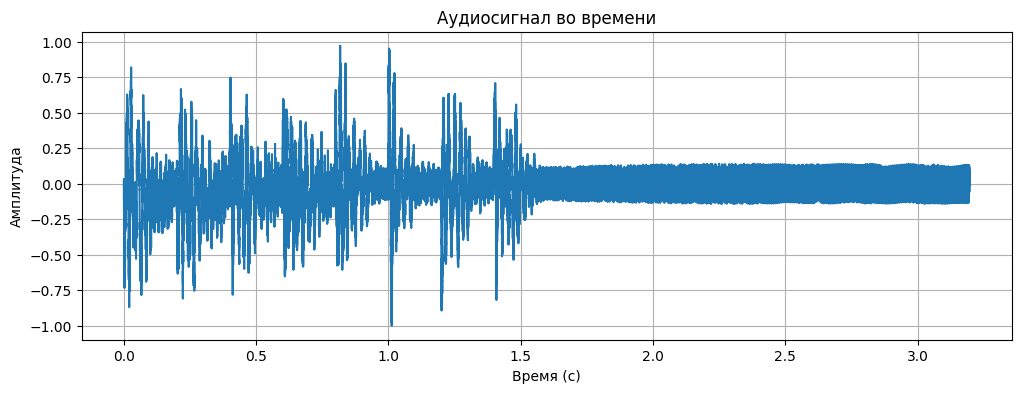

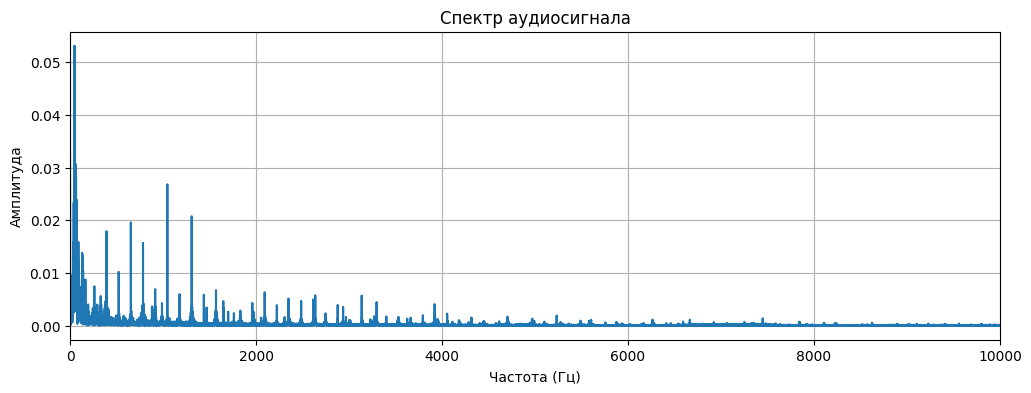

In [21]:
plt.figure(figsize=(12, 4))
plt.plot(t_audio, melody)
plt.title('Аудиосигнал во времени')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.grid(True)
plt.show()

N_audio = len(melody)
X_audio = np.fft.fft(melody)
freqs_audio = np.fft.fftfreq(N_audio, 1/fs_audio)
half_N = N_audio // 2

plt.figure(figsize=(12, 4))
plt.plot(freqs_audio[:half_N], np.abs(X_audio[:half_N]) * 2 / N_audio)
plt.title('Спектр аудиосигнала')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.xlim(0, 10000)
plt.grid(True)
plt.show()

**Вопрос:** До каких частот наблюдаются заметные пики в сигнале? Подумайте, какую частоту несущей можно выбрать при частоте дискретизации 44,1 кГц, чтобы эти пики не потерять. Как на это влияет выбор индекса модуляции ФМ-сигнала?

Заметные пики находятся в полосе вокруг несущей, ширина которой определяется параметрами ФМ (по правилу Карсона). При частоте дискретизации 44,1 кГц нужно выбирать несущую так, чтобы весь спектр сигнала оставался ниже ~22 кГц, иначе появится алиасинг.

При увеличении индекса модуляции β спектр расширяется (появляется больше боковых полос), поэтому несущую приходится выбирать ниже, чтобы все компоненты сигнала не выходили за допустимый диапазон.

### 4.2. Подготовка к модуляции (интерполяция)

Выберите частоту несущей в соответствии с ответом на предыдущий вопрос (если восстановленный сигнал будет сильно зашумлён, попробуйте другие значения).

In [22]:
fc_high = 5000 # несущая 5 кГц
Ac = 1

### 4.3. Модуляция аудиосигнала
Сгенерируйте модулированные сигналы. Индекс модуляции для ФМ-сигнала выберите так, чтобы несильно портить модулируемый сигнал.

In [23]:
# АМ
a_am = 0.2
s_am_audio = Ac * (1 + a_am * melody) * np.cos(2 * np.pi * fc_high * t_audio)

# ФМ
beta_pm_audio = 2
s_pm_audio = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_audio * melody)

### 4.4. Добавление шумов

**Амплитудный шум:** мультипликативный гауссов шум.

In [24]:
noise_amp = 0.1 * np.random.randn(len(t_audio))
s_am_noisy = s_am_audio * (1 + noise_amp)
s_pm_noisy = s_pm_audio * (1 + noise_amp)

### 4.5. Демодуляция сигналов

**Демодуляция АМ:**

Используйте преобразование Гильберта, чтобы демодулировать АМ-сигнал без шума, убедитесь, что качество звука изменилось незначительно.

In [25]:
analytic_am_clean = hilbert(s_am_audio)
envelope_clean = np.abs(analytic_am_clean)
demod_am_clean = (envelope_clean - Ac) / (Ac * a_am)

display(Audio(demod_am_clean, rate=fs_audio))

Демодулируйте зашумлёный АМ-сигнал.

In [26]:
analytic_am_noisy = hilbert(s_am_noisy)
envelope_noisy = np.abs(analytic_am_noisy)
demod_am_noisy = (envelope_noisy - Ac) / (Ac * a_am)

display(Audio(demod_am_noisy, rate=fs_audio))

**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $a_{AM}=0{,}2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,01. Попробуйте поменять $a_{AM}$, при каких амплитудах модуляции начинаются заметные искажения? Сделайте вывод о соотношении $a_{AM}$ и допустимых уровнях шума.

- Качество звука ухудшается при добавлении шума: сигнал становится менее чистым, появляются посторонние искажения.
- При фиксированном $a_{AM}=0{,}2$ заметная разница начинает проявляться, когда амплитуда шума становится достаточно большой (порядка нескольких процентов от сигнала) — звук становится «грязным» и теряет чёткость.
- Если зафиксировать шум на уровне 0.01, то при увеличении $a_{AM} сначала качество улучшается, но при слишком больших значениях появляются искажения. В целом, для хорошего качества важно, чтобы уровень модуляции был достаточно высоким по сравнению с шумом, но не чрезмерным.

**Демодуляция ФМ:**

Используйте метод аналитического сигнала для демодуляции ФМ-сигнала. Убедитесь, что качество звука изменилось незначительно.

In [27]:
analytic_pm_clean = hilbert(s_pm_audio)
inst_phase_clean = np.unwrap(np.angle(analytic_pm_clean))
phase_no_carrier_clean = inst_phase_clean - 2 * np.pi * fc_high * t_audio
demod_pm_clean = (phase_no_carrier_clean - np.mean(phase_no_carrier_clean)) / beta_pm_audio

display(Audio(demod_pm_clean, rate=fs_audio))

Демодулируйте зашумлёный ФМ-сигнал.

In [28]:
analytic_pm_noisy = hilbert(s_pm_noisy)
inst_phase_noisy = np.unwrap(np.angle(analytic_pm_noisy))
phase_no_carrier_noisy = inst_phase_noisy - 2 * np.pi * fc_high * t_audio
demod_pm_noisy = (phase_no_carrier_noisy - np.mean(phase_no_carrier_noisy)) / beta_pm_audio

display(Audio(demod_pm_noisy, rate=fs_audio))

**Вопросы:**
* Изменилось ли качество звука?
* Зафиксируйте $\beta=2$. Попробуйте поменять амплитуду шума. При каких значениях амплитуды вы слышите заметную разницу с оригиналом?
* Зафиксируйте амплитуду шума равную 0,1. Попробуйте поменять $\beta$. Как субъективная величина искажений зависит от $\beta$?

- Качество звука при ФМ меняется меньше, чем при АМ: даже при наличии шума сигнал воспринимается более устойчиво.
- При фиксированном 𝛽 = 2 заметные искажения начинают ощущаться при увеличении шума до сравнительно больших значений — ФМ лучше «держит» шум по сравнению с АМ.
- Если зафиксировать шум (например, 0.1), то с ростом β субъективное качество улучшается: сигнал становится устойчивее к шуму. Однако при слишком больших значениях возможны уже искажения из-за чрезмерного расширения спектра.

### 4.6. Сравнение спектров

Выберите значение амплитуды шума и величин $a_{AM}$ и $\beta$ так, чтобы искажения были заметны, но не велики. Постройте спектры исходного сигнала и сигналов, восстановлённых из зашумлённых АМ и ФМ-сигналов.

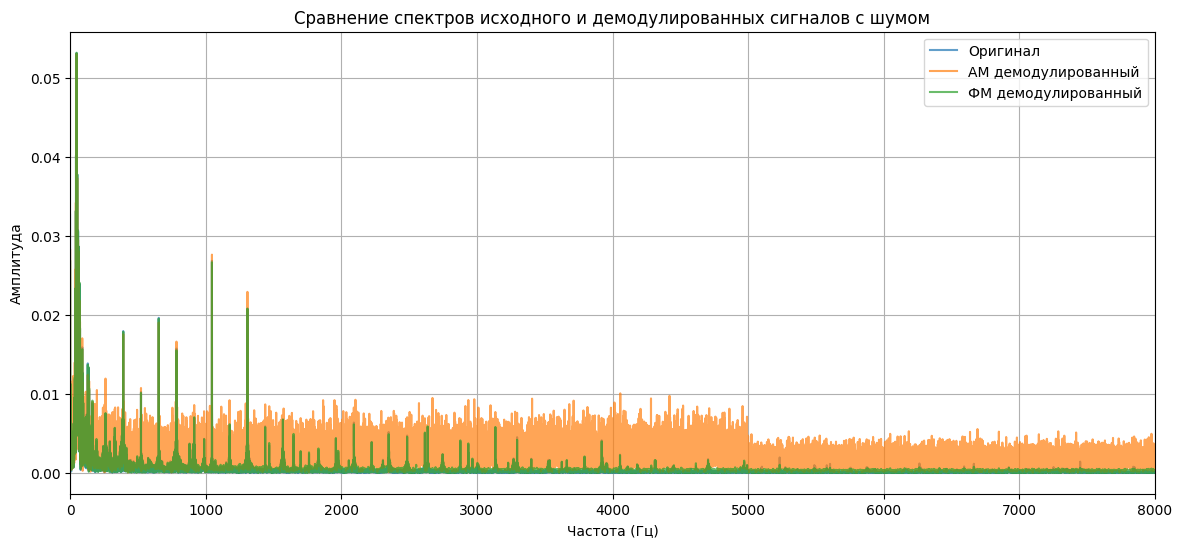

In [29]:
X_orig = np.fft.fft(melody)
X_am = np.fft.fft(demod_am_noisy)
X_pm = np.fft.fft(demod_pm_noisy)
freqs_cmp = np.fft.fftfreq(N_audio, 1/fs_audio)

plt.figure(figsize=(14, 6))
plt.plot(freqs_cmp[:half_N], np.abs(X_orig[:half_N])*2/N_audio, label='Оригинал', alpha=0.7)
plt.plot(freqs_cmp[:half_N], np.abs(X_am[:half_N])*2/N_audio, label='АМ демодулированный', alpha=0.7)
plt.plot(freqs_cmp[:half_N], np.abs(X_pm[:half_N])*2/N_audio, label='ФМ демодулированный', alpha=0.7)
plt.xlim(0, 8000)
plt.title('Сравнение спектров исходного и демодулированных сигналов с шумом')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:**
* Заметны ли визуально искажения спектров для случаев АМ и ФМ?

В спектрах различия заметны: у АМ структура проще (несущая и боковые полосы), а у ФМ спектр более сложный и широкий, особенно при больших 
𝛽.

Постройте спектры АМ и ФМ сигналов. Зафиксируйте $\beta=2$, подберите $a_{AM}$ так, чтобы амплитуды гармоник в обоих случаях были сравнимы по величине.

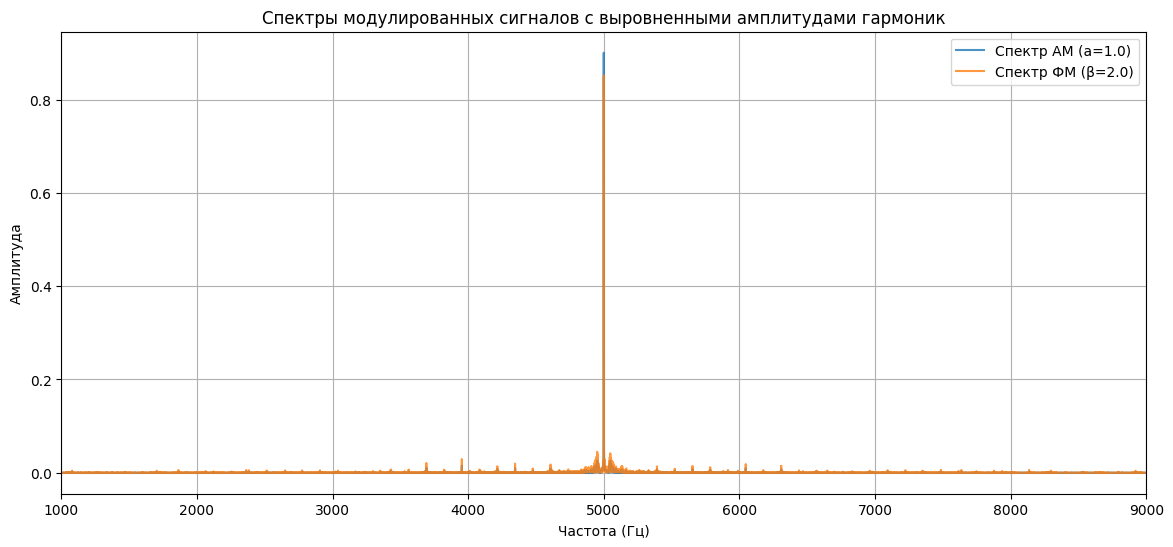

In [30]:
a_am_cmp = 1.0
beta_pm_cmp = 2.0

s_am_cmp = Ac * (1 + a_am_cmp * melody) * np.cos(2 * np.pi * fc_high * t_audio)
s_pm_cmp = Ac * np.cos(2 * np.pi * fc_high * t_audio + beta_pm_cmp * melody)

X_am_cmp = np.fft.fft(s_am_cmp)
X_pm_cmp = np.fft.fft(s_pm_cmp)

plt.figure(figsize=(14, 6))
plt.plot(freqs_cmp[:half_N], np.abs(X_am_cmp[:half_N])*2/N_audio, label=f'Спектр АМ (a={a_am_cmp})', alpha=0.8)
plt.plot(freqs_cmp[:half_N], np.abs(X_pm_cmp[:half_N])*2/N_audio, label=f'Спектр ФМ (β={beta_pm_cmp})', alpha=0.8)
plt.xlim(fc_high - 4000, fc_high + 4000)
plt.title('Спектры модулированных сигналов с выровненными амплитудами гармоник')
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)
plt.show()

**Вопрос:**
* При какой амплитуде шума в этом случае вы слышите заметные искажения АМ сигнала? А ФМ сигнала? Сделайте вывод.

Заметные искажения АМ появляются уже при относительно небольшом уровне шума. Для ФМ требуется более высокий уровень шума, чтобы услышать аналогичные искажения.
Вывод: ФМ-сигнал более устойчив к шуму, чем АМ.